In [33]:
import mne
import numpy as np
import pandas as pd
import os

from scipy.signal import welch
from scipy.stats import skew, kurtosis

# ================= PREPROCESSING =================
def preprocess_eeg(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

    # Rename channels
    mapping = {ch: ch.replace('EEG ', '').replace('-CPz', '').strip() for ch in raw.ch_names}
    raw.rename_channels(mapping)

    raw.pick("eeg")

    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')

    raw.filter(0.1, 30, verbose=False)
    raw.notch_filter(50, verbose=False)

    raw.set_eeg_reference('average')

    return raw


# ================= EPOCHING =================
def get_epochs(raw):
    events, event_id = mne.events_from_annotations(raw)

    epochs = mne.Epochs(
        raw, events, event_id=event_id,
        tmin=-0.2, tmax=0.8,
        baseline=(None, 0),
        preload=True,
        event_repeated='merge',
        verbose=False
    )

    return epochs


# ================= BANDPOWER =================
def bandpower(signal, sf, band):
    freqs, psd = welch(signal, sf, nperseg=int(sf*2))
    idx = (freqs >= band[0]) & (freqs <= band[1])
    return np.trapz(psd[idx], freqs[idx])


# ================= FEATURE EXTRACTION =================
def extract_features(epochs):
    important_channels = ['Pz', 'Cz', 'P3', 'P4']
    features = []

    sf = int(epochs.info['sfreq'])

    for trial in epochs.get_data():
        row = []

        for ch in important_channels:
            if ch in epochs.ch_names:
                idx = epochs.ch_names.index(ch)
                signal = trial[idx]
                times = epochs.times

                # -------- P300 WINDOW --------
                mask = (times >= 0.28) & (times <= 0.45)
                w_signal = signal[mask]
                w_time = times[mask]

                if len(w_signal) > 0:
                    peak_idx = np.argmax(w_signal)
                    amp = w_signal[peak_idx]
                    lat = w_time[peak_idx]
                else:
                    amp, lat = 0, 0

                # -------- TIME DOMAIN --------
                mean = np.mean(signal)
                std = np.std(signal)

                # -------- BANDPOWER --------
                delta = bandpower(signal, sf, (0.5, 4))
                theta = bandpower(signal, sf, (4, 8))
                alpha = bandpower(signal, sf, (8, 13))
                beta  = bandpower(signal, sf, (13, 30))

                # -------- ADL SCORE (COMPOSITE INDEX) --------
                adl = (alpha + beta) / (delta + theta + 1e-6)

                row.extend([
                    amp, lat,
                    mean, std,
                    delta, theta, alpha, beta,
                    adl
                ])

            else:
                row.extend([0]*9)

        features.append(row)

    return np.array(features), important_channels



# ================= PROCESS FOLDER =================
def process_folder(folder_path, label):
    X_all, y_all = [], []

    for file in os.listdir(folder_path):
        if file.endswith(".edf"):
            path = os.path.join(folder_path, file)
            print("Processing:", file)

            try:
                raw = preprocess_eeg(path)
                epochs = get_epochs(raw)

                for key in epochs.event_id.keys():
                    X, channels = extract_features(epochs[key])

                    if len(X) == 0:
                        continue

                    X_all.extend(X)
                    y_all.extend([label]*len(X))

            except Exception as e:
                print("Error:", file, e)

    return np.array(X_all), np.array(y_all), channels


# ================= RUN TBI =================
non_tbi_folder = r"E:\aditi_eeg\visual_eeg\non_tbi"

X_non, y_non, _ = process_folder(non_tbi_folder, label=0)

print("Non-TBI Shape:", X_non.shape)

Processing: a5_auditory_2026-04-07_11-28-57_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


C:\Users\HP\AppData\Local\Temp\ipykernel_304928\3349545195.py:60: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  for trial in epochs.get_data():
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 1025, using nperseg = 1025
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Processing: a5_auditory_2026-04-07_11-36-25_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


C:\Users\HP\AppData\Local\Temp\ipykernel_304928\3349545195.py:60: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  for trial in epochs.get_data():
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 1025, using nperseg = 1025
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Processing: a5_auditory_2026-04-07_11-45-44_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


...

Processing: p2_visual_2026-04-06_12-14-22_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 1025, using nperseg = 1025
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Processing: p3_vu=isual_2026-04-06_12-24-07_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


C:\Users\HP\AppData\Local\Temp\ipykernel_304928\3349545195.py:60: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  for trial in epochs.get_data():
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 1025, using nperseg = 1025
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Non-TBI Shape: (2095, 36)


In [34]:
# ================= COLUMN NAMES =================

columns = []

feature_names = [
    "amp", "lat",
    "mean", "std",
    "delta", "theta", "alpha", "beta",
    "adl_score"
]

for ch in channels:
    for f in feature_names:
        columns.append(f"{ch}_{f}")


# ================= CREATE DATAFRAME =================

import pandas as pd
import os
import numpy as np

df = pd.DataFrame(X_non, columns=columns)
df["Label"] = y_non


# ================= SAVE PATH =================

save_path = r"E:\aditi_eeg\visual_eeg\non_tbi_visual"
os.makedirs(save_path, exist_ok=True)


# ================= SAVE FILES =================

df.to_excel(os.path.join(save_path, "dataset.xlsx"), index=False)
df.to_csv(os.path.join(save_path, "dataset.csv"), index=False)

np.save(os.path.join(save_path, "X.npy"), X_non)
np.save(os.path.join(save_path, "y.npy"), y_non)


# ================= PRINT =================

print("Non-TBI files saved")
print("Shape:", X_non.shape)
print("Labels:", np.unique(y_non))

Non-TBI files saved
Shape: (2095, 36)
Labels: [0]


In [48]:
# ================= PRINT DATA INFO =================

print("Column Names:")
print(df.columns)

print("\nNumber of Columns:", df.shape[1])
print("Number of Rows:", df.shape[0])

print("\nFirst 5 Rows:")
print(df.head())

Column Names:
Index(['Pz_amp', 'Pz_lat', 'Pz_mean', 'Pz_std', 'Pz_delta', 'Pz_theta',
       'Pz_alpha', 'Pz_beta', 'Pz_adl_score', 'Cz_amp', 'Cz_lat', 'Cz_mean',
       'Cz_std', 'Cz_delta', 'Cz_theta', 'Cz_alpha', 'Cz_beta', 'Cz_adl_score',
       'P3_amp', 'P3_lat', 'P3_mean', 'P3_std', 'P3_delta', 'P3_theta',
       'P3_alpha', 'P3_beta', 'P3_adl_score', 'P4_amp', 'P4_lat', 'P4_mean',
       'P4_std', 'P4_delta', 'P4_theta', 'P4_alpha', 'P4_beta', 'P4_adl_score',
       'Label'],
      dtype='object')

Number of Columns: 37
Number of Rows: 2095

First 5 Rows:
     Pz_amp    Pz_lat   Pz_mean    Pz_std      Pz_delta      Pz_theta  \
0 -0.015090  0.280273 -0.014572  0.009931  1.462557e-05  2.451719e-09   
1  0.004932  0.449219  0.003388  0.002048  6.087149e-07  1.098990e-10   
2 -0.000149  0.449219 -0.000084  0.000140  5.877928e-09  7.738465e-13   
3  0.000004  0.280273 -0.000032  0.000056  6.420511e-10  4.228322e-13   
4  0.000021  0.416016  0.000017  0.000019  6.715961e-11  2.980351

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
✔ Non-TBI EEG loaded
Using channel: Pz


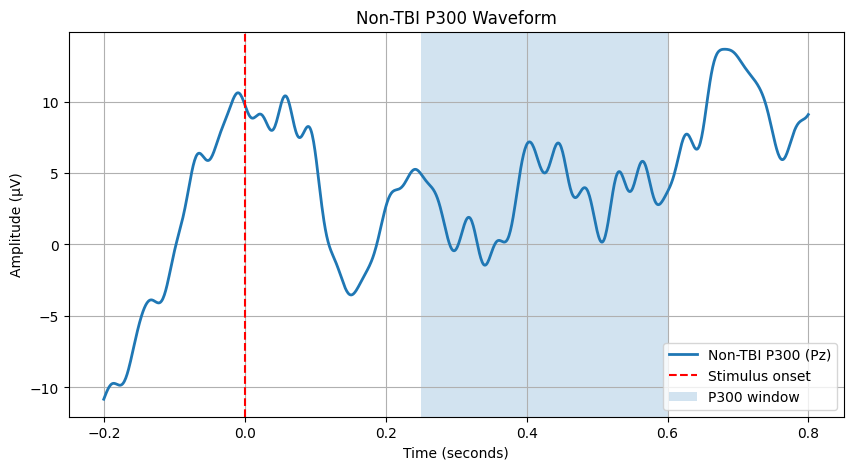

In [36]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# ================= FILE =================
file_path = r"E:\aditi_eeg\visual_eeg\non_tbi\p3_vu=isual_2026-04-06_12-24-07_Segment_0.edf"

# ================= LOAD + PREPROCESS =================
raw = preprocess_eeg(file_path)
epochs = get_epochs(raw)

print("✔ Non-TBI EEG loaded")

# ================= FIND Pz =================
channel = [ch for ch in epochs.ch_names if "Pz" in ch][0]
idx = epochs.ch_names.index(channel)

print("Using channel:", channel)

# ================= DATA =================
data = epochs.get_data()[:, idx, :]

# remove noisy trials
data = data[np.std(data, axis=1) < np.percentile(np.std(data, axis=1), 90)]

# ================= ERP =================
erp = np.mean(data, axis=0)
t = epochs.times

# baseline correction
erp = erp - np.mean(erp[t < 0])

# ================= PLOT =================
plt.figure(figsize=(10,5))

plt.plot(t, erp * 1e6, linewidth=2, label="Non-TBI P300 (Pz)")

plt.axvline(0, color="red", linestyle="--", label="Stimulus onset")
plt.axvspan(0.25, 0.60, alpha=0.2, label="P300 window")

plt.title("Non-TBI P300 Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.grid()

plt.show()

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impe

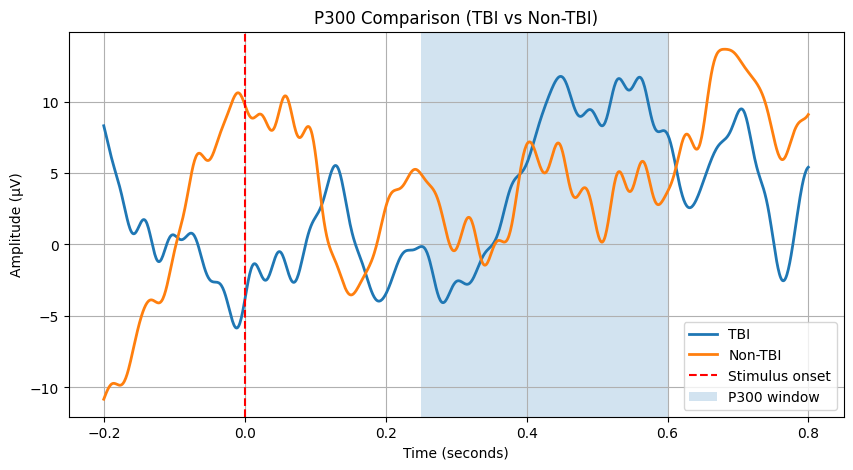

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# ================= FILES =================
tbi_file = r"E:\aditi_eeg\visual_eeg\tbi\p6_visual_2026-04-06_12-52-05_Segment_0.edf"
non_tbi_file = r"E:\aditi_eeg\visual_eeg\non_tbi\p3_vu=isual_2026-04-06_12-24-07_Segment_0.edf"
# ================= LOAD =================
tbi_raw = preprocess_eeg(tbi_file)
non_raw = preprocess_eeg(non_tbi_file)

tbi_epochs = get_epochs(tbi_raw)
non_epochs = get_epochs(non_raw)

print("✔ Both EEG files loaded")

# ================= FIND Pz =================
channel = [ch for ch in tbi_epochs.ch_names if "Pz" in ch][0]
idx = tbi_epochs.ch_names.index(channel)

print("Using channel:", channel)

# ================= FUNCTION =================
def get_erp(epochs, idx):

    data = epochs.get_data()[:, idx, :]

    # remove noisy trials
    data = data[np.std(data, axis=1) < np.percentile(np.std(data, axis=1), 90)]

    erp = np.mean(data, axis=0)
    t = epochs.times

    # baseline correction
    erp = erp - np.mean(erp[t < 0])

    return erp, t


# ================= ERP =================
tbi_erp, t = get_erp(tbi_epochs, idx)
non_erp, _ = get_erp(non_epochs, idx)

# ================= PLOT =================
plt.figure(figsize=(10,5))

plt.plot(t, tbi_erp * 1e6, label="TBI", linewidth=2)
plt.plot(t, non_erp * 1e6, label="Non-TBI", linewidth=2)

plt.axvline(0, color="red", linestyle="--", label="Stimulus onset")
plt.axvspan(0.25, 0.60, alpha=0.2, label="P300 window")

plt.title("P300 Comparison (TBI vs Non-TBI)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.grid()

plt.show()

In [52]:
import numpy as np

def get_p300_numbers(file_path):

    # ================= LOAD =================
    raw = preprocess_eeg(file_path)
    epochs = get_epochs(raw)

    # ================= FIND Pz =================
    channel = [ch for ch in epochs.ch_names if "Pz" in ch][0]
    idx = epochs.ch_names.index(channel)

    # ================= ERP =================
    data = epochs.get_data()[:, idx, :]

    # remove noisy trials
    data = data[np.std(data, axis=1) < np.percentile(np.std(data, axis=1), 90)]

    erp = np.mean(data, axis=0)
    t = epochs.times

    # baseline correction
    erp = erp - np.mean(erp[t < 0])

    # ================= P300 WINDOW =================
    mask = (t >= 0.25) & (t <= 0.60)

    window_signal = erp[mask]
    window_time = t[mask]

    # ================= METRICS =================
    peak_idx = np.argmax(window_signal)

    amplitude = window_signal[peak_idx] * 1e6   # convert to µV
    latency = window_time[peak_idx]

    return amplitude, latency

In [54]:
tbi_file = r"E:\aditi_eeg\visual_eeg\tbi\p6_visual_2026-04-06_12-52-05_Segment_0.edf"
non_tbi_file = r"E:\aditi_eeg\visual_eeg\non_tbi\p3_vu=isual_2026-04-06_12-24-07_Segment_0.edf"

tbi_amp, tbi_lat = get_p300_numbers(tbi_file)
non_amp, non_lat = get_p300_numbers(non_tbi_file)

print("\n===== NUMERICAL P300 VALUES =====")
print(f"TBI     → Amplitude: {tbi_amp:.4f} µV | Latency: {tbi_lat:.3f} s")
print(f"Non-TBI → Amplitude: {non_amp:.4f} µV | Latency: {non_lat:.3f} s")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impe

In [40]:
import mne
import numpy as np

# ================= FUNCTION =================
def get_psd_values(file_path):

    raw = preprocess_eeg(file_path)

    raw.pick_types(eeg=True)

    # ================= PSD (NEW MNE METHOD) =================
    psd_obj = raw.compute_psd(fmin=0.5, fmax=30, n_fft=1024)
    psds, freqs = psd_obj.get_data(return_freqs=True)

    # average across channels
    psd_mean = np.mean(psds, axis=0)

    # ================= BAND POWER =================
    delta = np.mean(psd_mean[(freqs >= 0.5) & (freqs < 4)])
    theta = np.mean(psd_mean[(freqs >= 4) & (freqs < 8)])
    alpha = np.mean(psd_mean[(freqs >= 8) & (freqs < 13)])
    beta  = np.mean(psd_mean[(freqs >= 13) & (freqs < 30)])

    return delta, theta, alpha, beta

In [41]:
tbi_file = r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf"
non_tbi_file = r"E:\aditi_eeg\visual_eeg\non_tbi\p3_vu=isual_2026-04-06_12-24-07_Segment_0.edf"

tbi_psd = get_psd_values(tbi_file)
non_psd = get_psd_values(non_tbi_file)

print("\n===== PSD VALUES =====")

print("\nTBI:")
print(tbi_psd)

print("\nNon-TBI:")
print(non_psd)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 1.000 (s)
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 1.000 (s)

===== PSD VALUES =====

TBI:
(3.7272242573763353e-07, 6.929686969553275e-09, 1.399732749654299e-09, 2.0490123960374838e-10)

Non-TBI:
(4.4599593625714917e-07, 1.1251872976799014e-08, 1.8200786799763307e-09, 3.7967243083931247e-10)


In [42]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# ================= FUNCTION =================
def get_band_topomap(file_path, band=(8, 13)):  # alpha band default

    raw = preprocess_eeg(file_path)
    raw.pick_types(eeg=True)

    # compute PSD
    psd_obj = raw.compute_psd(fmin=0.5, fmax=30, n_fft=1024)
    psds, freqs = psd_obj.get_data(return_freqs=True)

    # band mask
    mask = (freqs >= band[0]) & (freqs <= band[1])

    # band power per channel
    band_power = np.mean(psds[:, mask], axis=1)

    return raw, band_power

In [55]:
tbi_file = r"E:\aditi_eeg\visual_eeg\tbi\p6_visual_2026-04-06_12-52-05_Segment_0.edf"
non_tbi_file = r"E:\aditi_eeg\visual_eeg\non_tbi\p3_vu=isual_2026-04-06_12-24-07_Segment_0.edf"

tbi_raw, tbi_power = get_band_topomap(tbi_file, band=(8, 13))  # alpha
non_raw, non_power = get_band_topomap(non_tbi_file, band=(8, 13))

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 1.000 (s)
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 1.000 (s)


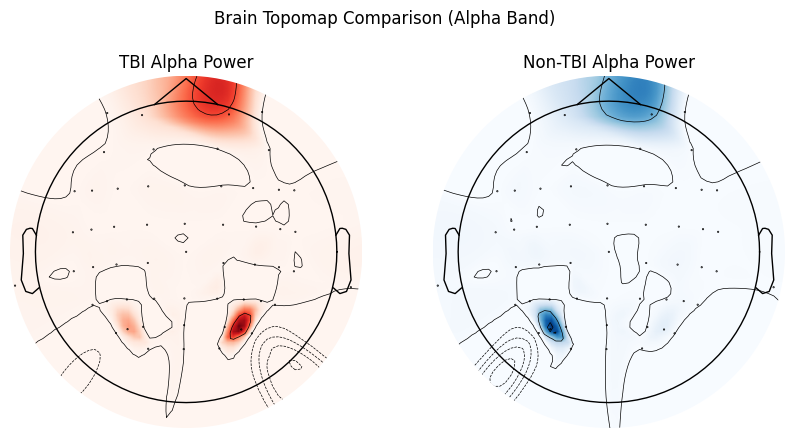

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

mne.viz.plot_topomap(
    tbi_power,
    tbi_raw.info,
    axes=ax[0],
    show=False,
    cmap="Reds"
)
ax[0].set_title("TBI Alpha Power")

mne.viz.plot_topomap(
    non_power,
    non_raw.info,
    axes=ax[1],
    show=False,
    cmap="Blues"
)
ax[1].set_title("Non-TBI Alpha Power")

plt.suptitle("Brain Topomap Comparison (Alpha Band)")
plt.show()

In [46]:
# Theta band = 4–8 Hz

tbi_raw_theta, tbi_theta_power = get_band_topomap(tbi_file, band=(4, 8))
non_raw_theta, non_theta_power = get_band_topomap(non_tbi_file, band=(4, 8))

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 1.000 (s)
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 1.000 (s)


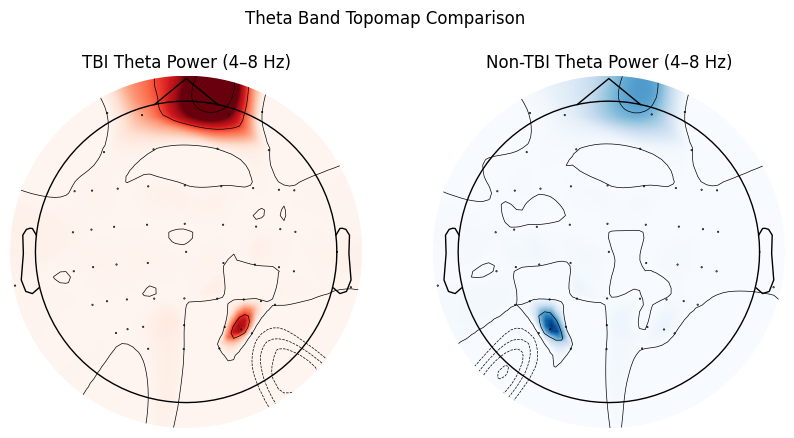

In [47]:
import matplotlib.pyplot as plt
import mne

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

mne.viz.plot_topomap(
    tbi_theta_power,
    tbi_raw_theta.info,
    axes=ax[0],
    show=False,
    cmap="Reds"
)
ax[0].set_title("TBI Theta Power (4–8 Hz)")

mne.viz.plot_topomap(
    non_theta_power,
    non_raw_theta.info,
    axes=ax[1],
    show=False,
    cmap="Blues"
)
ax[1].set_title("Non-TBI Theta Power (4–8 Hz)")

plt.suptitle("Theta Band Topomap Comparison")
plt.show()